# BESS Dispatch Optimizer — Module 1: Data Fetch
Run these cells top-to-bottom to verify `data_fetch.py` is working correctly.
This notebook uses **mock data** so no internet connection to NYISO is needed.

In [ ]:
# ── 0. Install dependencies (only needed once) ────────────────────────────
# Uncomment and run this cell if you haven't installed the requirements yet.
# !pip install pandas requests pulp matplotlib pytz jupyter

In [1]:
# ── 1. Imports & path setup ───────────────────────────────────────────────
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))   # make sure data_fetch.py is importable

from data_fetch import fetch_lmp, load_lmp, generate_mock_lmp, NYISO_ZONES
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DB = "bess_lmp.db"
NODE = "CAPITL"
START, END = "2025-01-01", "2025-01-14"      # two weeks

print("Imports OK")
print("Available NYISO zones:", NYISO_ZONES)

Imports OK
Available NYISO zones: ['CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'H Q', 'HUD VL', 'LONGIL', 'MHK VL', 'MILLWD', 'N.Y.C.', 'NORTH', 'NPX', 'O H', 'PJM', 'WEST']


In [2]:
# ── 2. Generate synthetic LMP data ────────────────────────────────────────
# This writes realistic mock prices to SQLite — no NYISO access needed.
# When you're ready to use real data, swap this cell for fetch_lmp() instead.
df_mock = generate_mock_lmp(START, END, node=NODE, db_path=DB, seed=42)

print(f"Generated {len(df_mock):,} hourly rows")
df_mock.head()

Generated 336 hourly rows


,interval_start,node,lmp,mcl,mcc
0,2025-01-01 00:00:00+00:00,CAPITL,31.227255,0.780443,-0.045372
1,2025-01-01 01:00:00+00:00,CAPITL,25.894751,0.772600,0.196931
2,2025-01-01 02:00:00+00:00,CAPITL,33.279530,0.686499,-0.448087
3,2025-01-01 03:00:00+00:00,CAPITL,34.860682,0.808765,0.234725
4,2025-01-01 04:00:00+00:00,CAPITL,25.579241,0.410537,-0.126122


In [3]:
# ── 3. Load from SQLite (what the optimizer will call) ────────────────────
df = load_lmp(START, END, node=NODE, db_path=DB)

print(f"Loaded {len(df):,} rows from {DB}")
print(f"Date range : {df['interval_start'].min()} → {df['interval_start'].max()}")
print(f"Timezone   : {df['interval_start'].dt.tz}")
print("\nColumn dtypes:")
print(df.dtypes)

Loaded 336 rows from bess_lmp.db
Date range : 2025-01-01 00:00:00+00:00 → 2025-01-14 23:00:00+00:00
Timezone   : UTC

Column dtypes:
interval_start    datetime64[ns, UTC]
node                           object
lmp                           float64
mcl                           float64
mcc                           float64
dtype: object


In [4]:
# ── 4. Basic assertions ───────────────────────────────────────────────────
expected_hours = (pd.Timestamp(END) - pd.Timestamp(START)).days * 24 + 24

assert len(df) == expected_hours, f"Expected {expected_hours} rows, got {len(df)}"
assert df['interval_start'].dt.tz is not None, "Timestamps must be tz-aware"
assert df['lmp'].notna().all(), "No NaN LMPs allowed"
gaps = df['interval_start'].diff().dropna()
assert (gaps == pd.Timedelta('1h')).all(), "Hourly frequency broken"

print("✅ All assertions passed")

✅ All assertions passed


In [5]:
# ── 5. Summary statistics ─────────────────────────────────────────────────
stats = df['lmp'].describe().rename('LMP ($/MWh)')
print(stats.to_string())
print(f"\nNegative-price hours : {(df['lmp'] < 0).sum()}")
print(f"Spike hours (>$100)  : {(df['lmp'] > 100).sum()}")

count    336.000000
mean      39.673215
std       17.818229
min       15.677380
25%       29.901484
50%       35.871425
75%       44.996269
max      139.257948

Negative-price hours : 0
Spike hours (>$100)  : 10


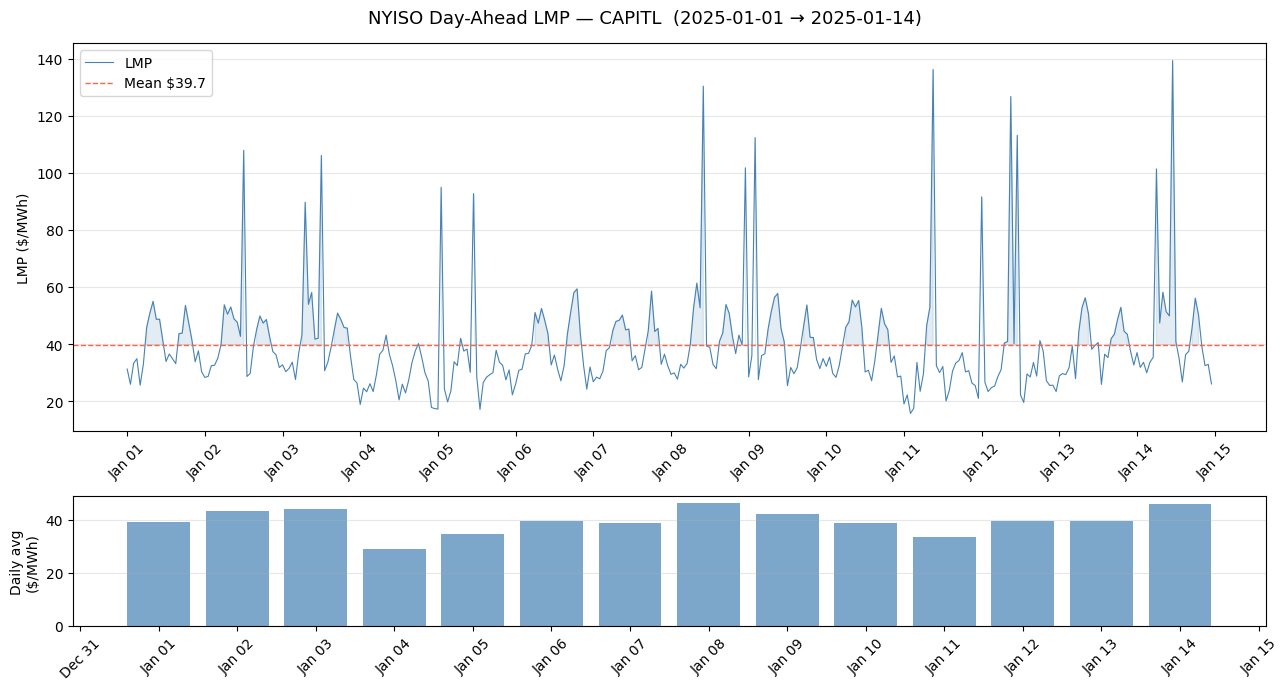

Saved lmp_preview.png


In [6]:
# ── 6. Visualise price curve ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(f"NYISO Day-Ahead LMP — {NODE}  ({START} → {END})", fontsize=13)

# Top: hourly LMP time series
ax = axes[0]
ax.plot(df['interval_start'], df['lmp'], color='steelblue', lw=0.8, label='LMP')
ax.axhline(df['lmp'].mean(), color='tomato', ls='--', lw=1, label=f"Mean ${df['lmp'].mean():.1f}")
ax.fill_between(df['interval_start'], df['lmp'], df['lmp'].mean(),
                where=df['lmp'] > df['lmp'].mean(), alpha=0.15, color='steelblue')
ax.set_ylabel('LMP ($/MWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Bottom: daily average bar chart
ax2 = axes[1]
daily = df.set_index('interval_start').resample('D')['lmp'].mean()
ax2.bar(daily.index, daily.values, width=0.8, color='steelblue', alpha=0.7)
ax2.set_ylabel('Daily avg\n($/MWh)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("lmp_preview.png", dpi=150)
plt.show()
print("Saved lmp_preview.png")

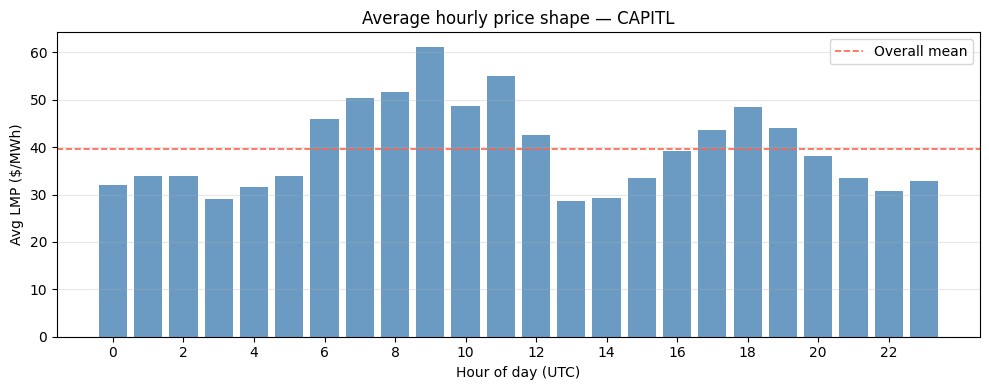

Peak hour  : 09:00 UTC  ($61.19/MWh)
Trough hour: 13:00 UTC  ($28.68/MWh)
Avg daily spread: $32.51/MWh  ← arbitrage opportunity


In [7]:
# ── 7. Average hourly price shape (useful for optimizer intuition) ─────────
df['hour'] = df['interval_start'].dt.hour
hourly_avg = df.groupby('hour')['lmp'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly_avg.index, hourly_avg.values, color='steelblue', alpha=0.8)
ax.axhline(hourly_avg.mean(), color='tomato', ls='--', lw=1.2, label='Overall mean')
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Avg LMP ($/MWh)')
ax.set_title(f'Average hourly price shape — {NODE}')
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

peak_h = int(hourly_avg.idxmax())
trough_h = int(hourly_avg.idxmin())
spread = hourly_avg.max() - hourly_avg.min()
print(f"Peak hour  : {peak_h:02d}:00 UTC  (${hourly_avg.max():.2f}/MWh)")
print(f"Trough hour: {trough_h:02d}:00 UTC  (${hourly_avg.min():.2f}/MWh)")
print(f"Avg daily spread: ${spread:.2f}/MWh  ← arbitrage opportunity")

In [10]:
# ── 8. (Optional) Fetch REAL data from NYISO ─────────────────────────────
# Uncomment to fetch actual historical prices — requires internet access.
# NYISO keeps roughly 1 year of daily archives publicly available.
#
df_real = fetch_lmp(
     start="2025-01-01",
     end="2025-01-07",
     node="CAPITL",
     db_path=DB,
 )
print(df_real.head())

print("Skipping real fetch — using mock data for now.")
print("\n✅ data_fetch.py is ready. Next: build optimizer.py")

             interval_start    node        lmp       mcl       mcc
0 2025-01-01 00:00:00+00:00  CAPITL  31.227255  0.780443 -0.045372
1 2025-01-01 01:00:00+00:00  CAPITL  25.894751  0.772600  0.196931
2 2025-01-01 02:00:00+00:00  CAPITL  33.279530  0.686499 -0.448087
3 2025-01-01 03:00:00+00:00  CAPITL  34.860682  0.808765  0.234725
4 2025-01-01 04:00:00+00:00  CAPITL  25.579241  0.410537 -0.126122
Skipping real fetch — using mock data for now.

✅ data_fetch.py is ready. Next: build optimizer.py
